<a href="https://colab.research.google.com/github/mmkeerthi28-blip/SHAP_Neural_Network_XAI/blob/main/SHAP_Neural_Network_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install shap tensorflow scikit-learn pandas matplotlib -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])
print("Classes:", data.target_names)

Dataset shape: (569, 30)
Number of features: 30
Number of samples: 569
Classes: ['malignant' 'benign']


In [4]:
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30,)),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6291 - loss: 0.6369 - val_accuracy: 0.9560 - val_loss: 0.4849
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9505 - loss: 0.4246 - val_accuracy: 0.9780 - val_loss: 0.3305
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9615 - loss: 0.2849 - val_accuracy: 0.9890 - val_loss: 0.2139
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9643 - loss: 0.1823 - val_accuracy: 0.9890 - val_loss: 0.1489
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9670 - loss: 0.1320 - val_accuracy: 0.9890 - val_loss: 0.1159
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9753 - loss: 0.1070 - val_accuracy: 0.9890 - val_loss: 0.0956
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9725 - loss: 0.0915 - val_accuracy: 0.9890 - val_loss: 0.0817
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9780 - loss: 0.0815 - val_accuracy: 0.9890 - v

In [10]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9649 - loss: 0.0913
Test Loss: 0.09133070707321167
Test Accuracy: 0.9649122953414917


In [11]:
predictions = model.predict(X_test)

print(predictions[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[1.08225684e-07]
 [9.99972880e-01]
 [6.42052107e-03]
 [3.32391232e-01]
 [7.29863459e-09]
 [9.95320022e-01]
 [9.99791205e-01]
 [2.54730935e-06]
 [3.98375378e-05]
 [1.23773908e-10]]


In [12]:
predicted_classes = (predictions >= 0.5).astype(int)

print("Predicted:", predicted_classes[:10].flatten())
print("Actual:   ", y_test[:10])

Predicted: [0 1 0 0 0 1 1 0 0 0]
Actual:    [0 1 0 1 0 1 1 0 0 0]


In [13]:
background = X_train[:100]

In [14]:
explainer = shap.Explainer(
    model,
    background
)

In [15]:
shap_values = explainer(X_test[:50])

PermutationExplainer explainer: 51it [00:14,  2.64it/s]                        


/tmp/ipykernel_1037/1479708973.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


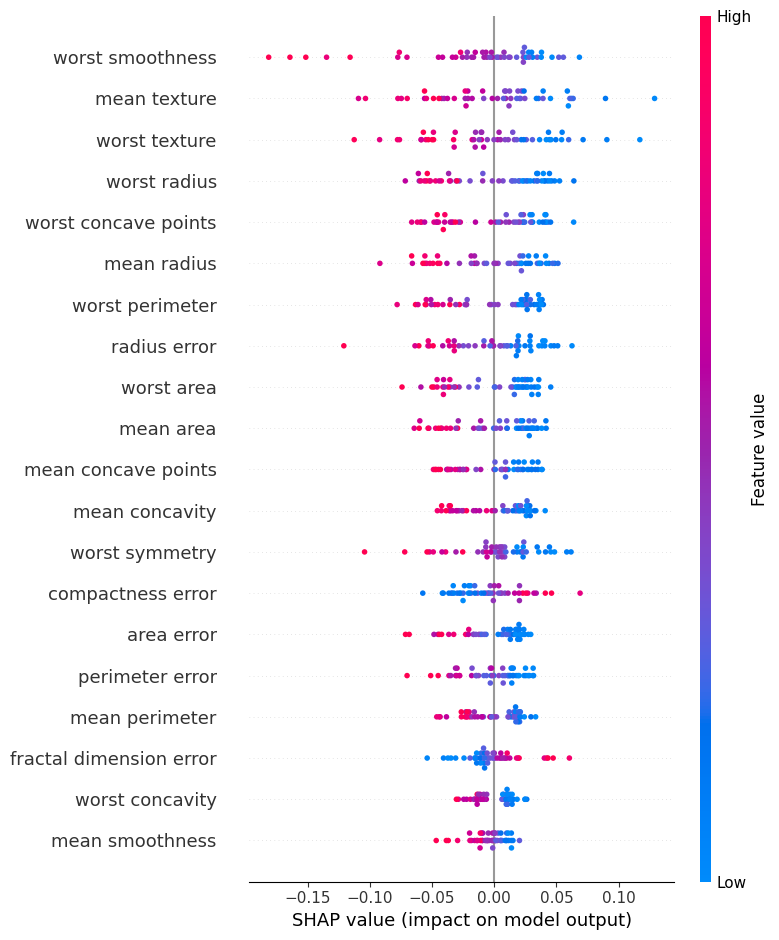

In [16]:
shap.summary_plot(
    shap_values.values,
    X_test[:50],
    feature_names=data.feature_names
)

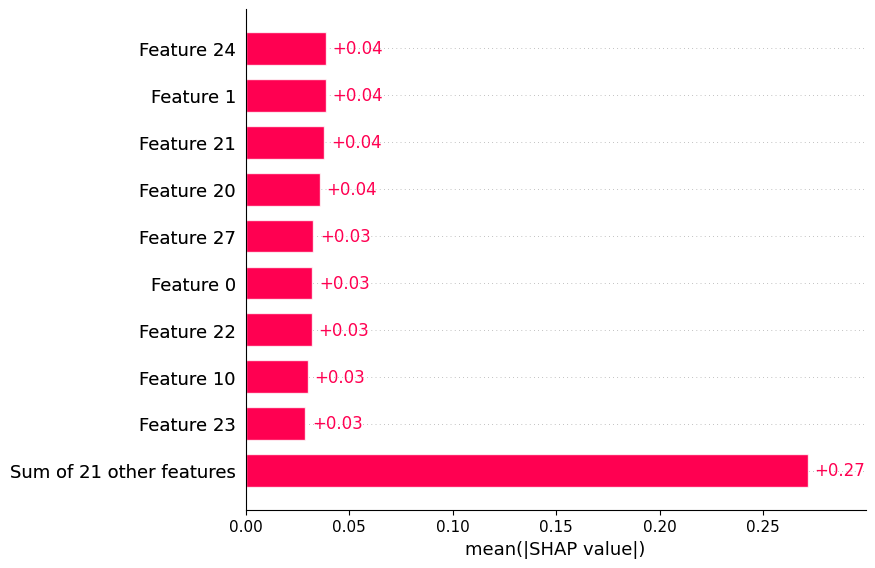

In [17]:
shap.plots.bar(shap_values)

In [18]:
sample = X_test[0:1]

sample_shap = explainer(sample)

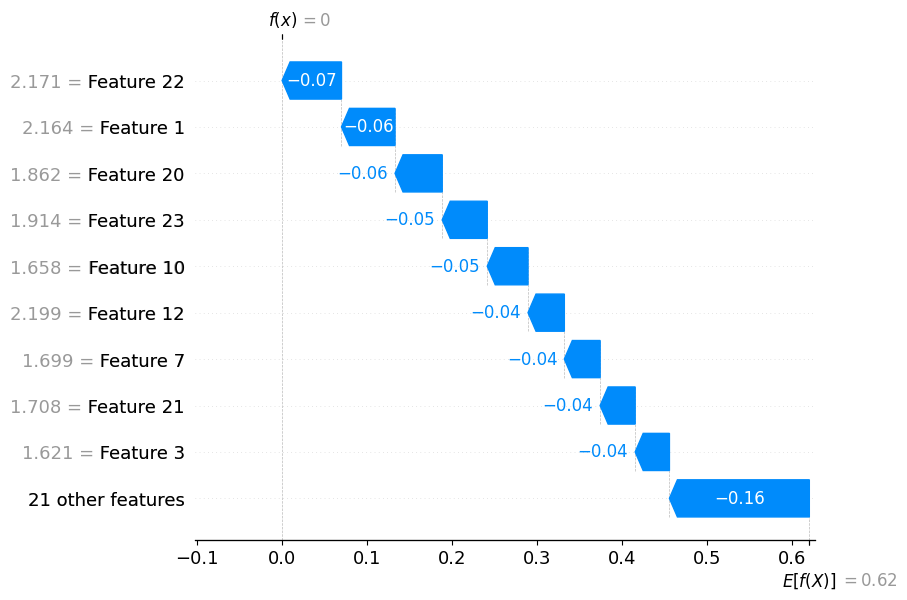

In [19]:
shap.plots.waterfall(sample_shap[0])

In [20]:
prediction = model.predict(sample)[0][0]

print("Prediction probability:", prediction)

if prediction >= 0.5:
    print("Predicted class: Benign")
else:
    print("Predicted class: Malignant")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction probability: 1.08225656e-07
Predicted class: Malignant
